In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## load the dataset

In [2]:
df=pd.read_csv(r"C:\Users\hindu\Desktop\car_price linear_regression\data\processed\cleaned_car_price_dataset.csv")

In [3]:
df.head(5)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [5]:
df.shape

(10000, 10)

###  checking for missing values

In [6]:
df.isnull().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

In [7]:
df.describe()

,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2011.543700,3.000560,149239.111800,3.497100,2.991100,8852.96440
std,6.897699,1.149324,86322.348957,1.110097,1.422682,3112.59681
min,2000.000000,1.000000,25.000000,2.000000,1.000000,2000.00000
25%,2006.000000,2.000000,74649.250000,3.000000,2.000000,6646.00000
50%,2012.000000,3.000000,149587.000000,3.000000,3.000000,8858.50000
75%,2017.000000,4.000000,223577.500000,4.000000,4.000000,11086.50000
max,2023.000000,5.000000,299947.000000,5.000000,5.000000,18301.00000


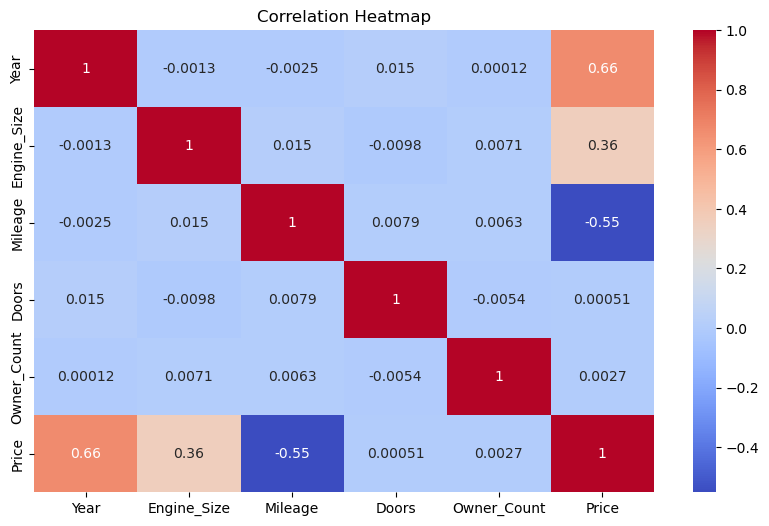

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

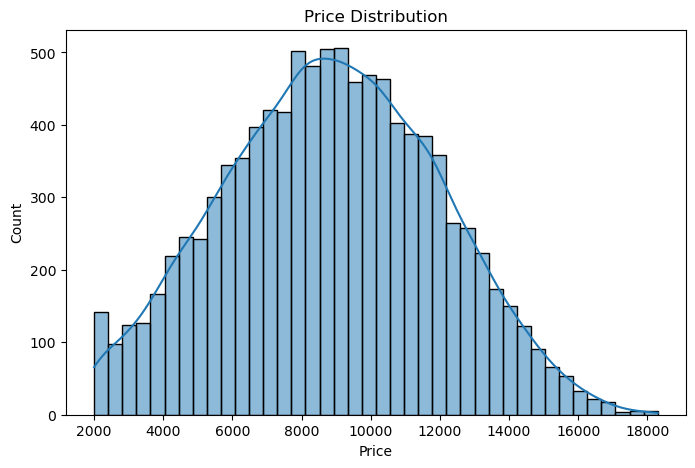

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["Price"],
    kde=True
)
plt.title("Price Distribution")
plt.show()

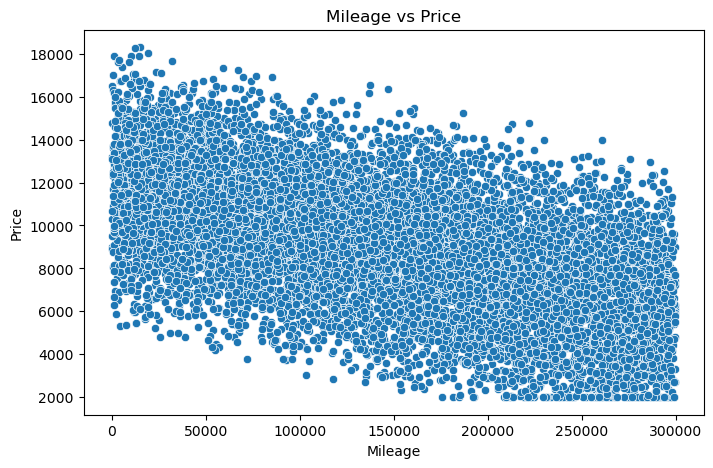

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["Mileage"],
    y=df["Price"]
)
plt.title("Mileage vs Price")
plt.show()

### outlier detection


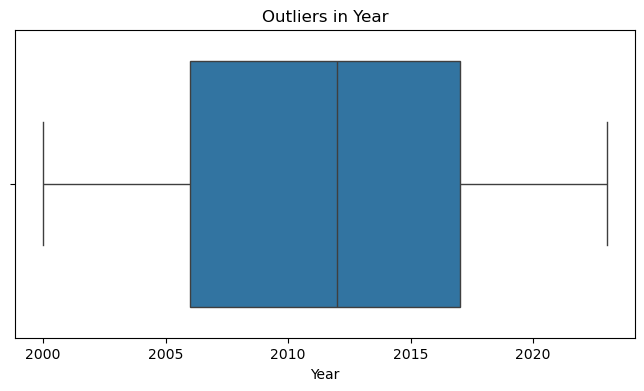

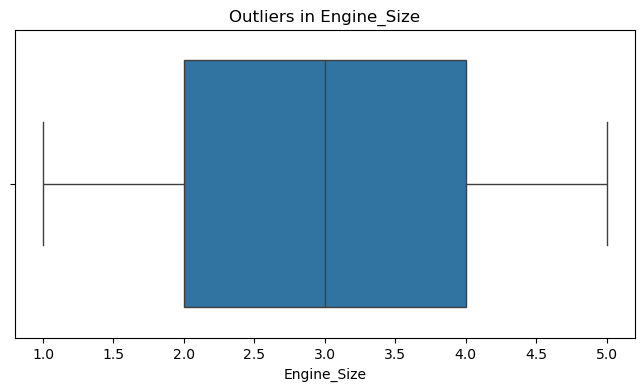

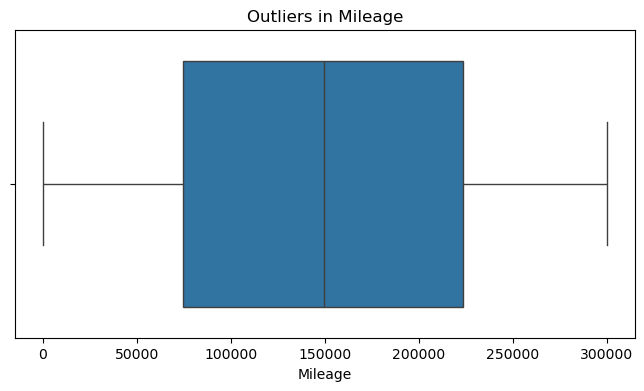

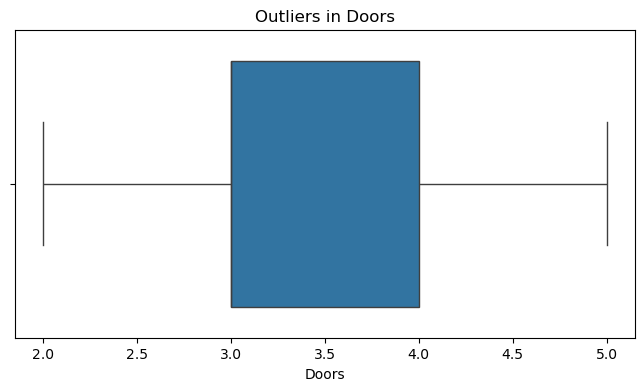

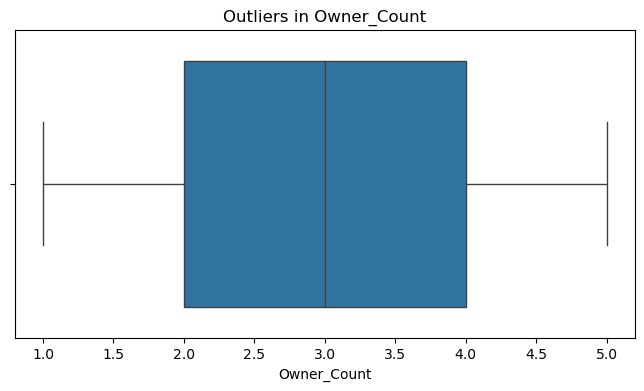

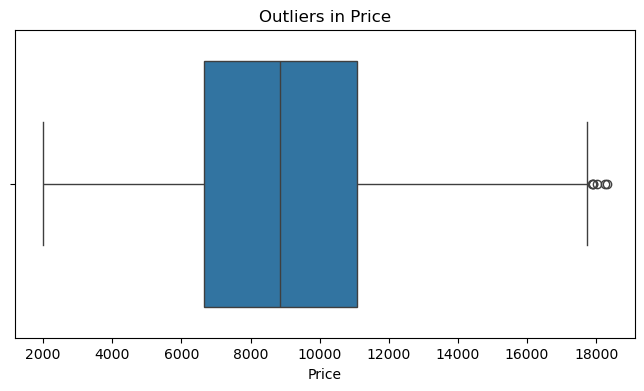

In [ ]:
numerical_cols = [
    "Year",
    "Engine_Size",
    "Mileage",
    "Doors",
    "Owner_Count",
    "Price"
]
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

### IQR method


In [ ]:

Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Lower Bound: -14.75
Upper Bound: 17747.25


###  remove outliers

In [13]:
df_no_outliers = df[
    (df["Price"] >= lower_bound)
    &
    (df["Price"] <= upper_bound)
]


In [14]:
print("Original Shape:", df.shape)

print("After Removing Outliers:", df_no_outliers.shape)


Original Shape: (10000, 10)
After Removing Outliers: (9994, 10)


In [15]:
df_no_outliers.to_csv(
    "../data/processed/cleaned_no_outliers.csv",
    index=False
)

print("Outliers removed successfully")

Outliers removed successfully


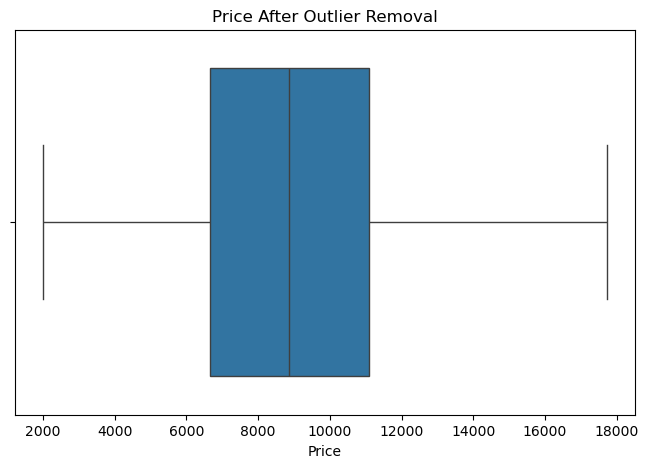

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df_no_outliers["Price"]
)
plt.title("Price After Outlier Removal")
plt.show()